In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from natsort import natsorted
from alntk.alignment import Alignment, find_sequence, write_to_fasta
from alntk.sector import highlight_sector
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

In [2]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype=str)
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)

In [3]:
red_sector

array([243, 201, 241, 228, 229, 204, 192, 189, 193, 165,   2, 242, 233,
       235, 198, 197, 177])

In [4]:
red_sector_sorted = red_sector.copy()
red_sector_sorted.sort()

In [5]:
red_sector_sorted[1:].min(), red_sector_sorted[1:].max(), red_sector_sorted[1:].max() - red_sector_sorted[1:].min(), num[red_sector_sorted[1:].min()], num[red_sector_sorted[1:].max()]

(np.int64(165), np.int64(243), np.int64(78), np.str_('160'), np.str_('228'))

In [6]:
num[red_sector]

array(['228', '189', '226', '215', '216', '192', '183', '180', '184',
       '160', '18', '227', '219', '221', '188a', '188', '172'],
      dtype='<U4')

In [7]:
np.array(natsorted(num[red_sector]))

array(['18', '160', '172', '180', '183', '184', '188', '188a', '189',
       '192', '215', '216', '219', '221', '226', '227', '228'],
      dtype='<U4')

In [8]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [9]:
seqs = aln.get_seqs()
descs = aln.get_descs()

In [10]:
with open("../data/iter_aln_v2_redsector.faa", "w") as f:
    for d, s in zip(descs, seqs[:, red_sector_sorted]):
        f.write(">"+d)
        f.write("\n")
        f.write("".join(s))
        f.write("\n")

In [11]:
seqs_red = seqs[:, red_sector_sorted]

In [12]:
def find_representative(aln, identity_threshold, show_steps=False, seed=42):
    # choose the threshold of identity below which removing sequences
    # identity_threshold = 5
    
    # our red sector alignment is L=17 long and has N=89439 sequences
    N, L = aln.shape
    
    # seed the random generator
    np.random.seed(seed)
    
    # initialize the "remaining" set with all the sequences
    remaining = set(range(N))
    
    # initialize the empty list of sequences that are "representatives"
    representatives = []
    
    # while the set of remaining sequences is not depleted
    step = 0
    while remaining:
        step += 1
        # choose a random member of the remaining set
        curr_idx = np.random.choice(list(remaining))
        curr_seq = aln[curr_idx]
    
        # look for the residues that are equal to the current sequence
        # and sum over the resulting array, to compute the identity
        identity_values = np.sum(curr_seq == aln, axis=1)
        # remove the sequences that are closer than the threshold to the current sequence
        too_similar = set(np.where(identity_values >= identity_threshold)[0])
        to_remove = too_similar & remaining
    
        if len(to_remove) == 0:
            # This should only happen if remaining is empty, otherwise something is wrong
            print("WARNING: no sequences removed but remaining is non-empty!")
            break
    
        if (step % 100 == 0) & (show_steps):
            print("step:", step)
            print("remaining:", len(remaining))
            
        remaining -= to_remove
        representatives.append(curr_idx)
    
    print("Found set of representative sequences! Size is", len(representatives))
    return representatives

In [13]:
rep_sizes = []
for i in range(14):
    representatives = find_representative(seqs_red, identity_threshold=i)
    rep_sizes.append(len(representatives))

Found set of representative sequences! Size is 1
Found set of representative sequences! Size is 3
Found set of representative sequences! Size is 6
Found set of representative sequences! Size is 21


Found set of representative sequences! Size is 53


Found set of representative sequences! Size is 159


Found set of representative sequences! Size is 400


Found set of representative sequences! Size is 899


...

Found set of representative sequences! Size is 3024


Found set of representative sequences! Size is 4786


Found set of representative sequences! Size is 7045


Found set of representative sequences! Size is 9755


Found set of representative sequences! Size is 13086


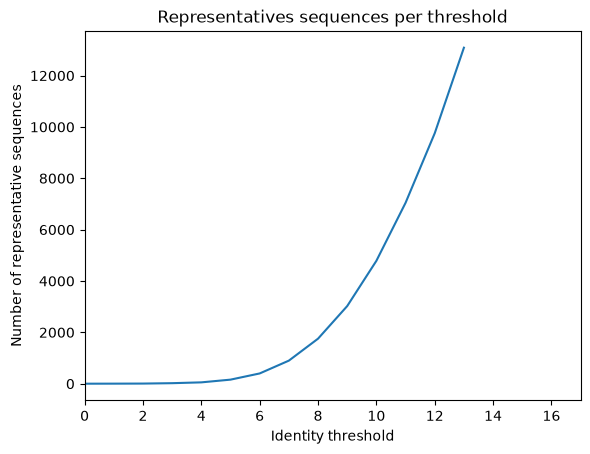

In [14]:
plt.figure()
plt.title("Representatives sequences per threshold")
plt.plot(rep_sizes)
plt.xlabel("Identity threshold")
plt.ylabel("Number of representative sequences")
plt.xlim([0, 17])
plt.show()

In [15]:
representatives = find_representative(seqs_red, identity_threshold=7, seed=3)
seqs_red_rep = seqs_red[representatives]

Found set of representative sequences! Size is 882


## PCA of red sector

In [16]:
ch_accs = ["P07338", "P17538", "P80646", "P00767", "Q7M3E1", "Q61759", "Q6GPI", "P04813", "P00766"]
tr_accs = ["P00760", "P07477", "P00762", "P07478", "P35030", "Q9R0T7", "P07146", "P00763", "P35031", "P35033"]
el_accs = ["P08217", "P08218", "P08419", "Q7SIG3", "P05208", "P00773", "Q91X79", "P00772", "Q29461", "P09093", "Q28153", "P00774"]

In [17]:
ch_idxs, tr_idxs, el_idxs = [], [], []

for desc_idx, desc in enumerate(descs):
    for accession in desc.split("_"):
        if accession in ch_accs:
            ch_idxs.append(desc_idx)
        elif accession in tr_accs:
            tr_idxs.append(desc_idx)
        elif accession in el_accs:
            el_idxs.append(desc_idx)

In [18]:
reference_seqs = seqs_red.copy()

seed = 42
representatives = find_representative(seqs_red, identity_threshold=7, seed=seed)

ohe = OneHotEncoder(handle_unknown='ignore')
reference_seqs_ohe = ohe.fit_transform(reference_seqs)

pca = PCA(n_components=3, svd_solver='arpack')
pca.fit(reference_seqs_ohe)
reference_pca_unweighted = pca.transform(reference_seqs_ohe)

Found set of representative sequences! Size is 899


## Weighted PCA of red sector (columns scaled by ICA loading)

Instead of one-hot encoding every red-sector position equally, we scale each position's one-hot columns by that position's ICA loading on the red-sector independent component (`pySCA/notebooks/05_findsector.ipynb`, `db["sector"]["Vica"]`). Positions with a stronger IC loading (more central to the sector) are given more weight in the PCA distance metric than peripheral, weakly-coevolving positions.

In [19]:
icweights = np.loadtxt("../data/iter_aln_v2_redsector_icweights.txt")
# icweights is in the same (IC-loading-descending) order as red_sector;
# reorder to match red_sector_sorted, which is what seqs_red's columns follow.
weights_sorted = icweights[np.argsort(red_sector)]
weights_sorted

array([0.15160528, 0.15238936, 0.10134617, 0.19186386, 0.2084773 ,
       0.18391381, 0.10885534, 0.11009085, 0.39034274, 0.21285608,
       0.26295484, 0.23427769, 0.12552519, 0.11646293, 0.32253124,
       0.13237006, 0.40103144])

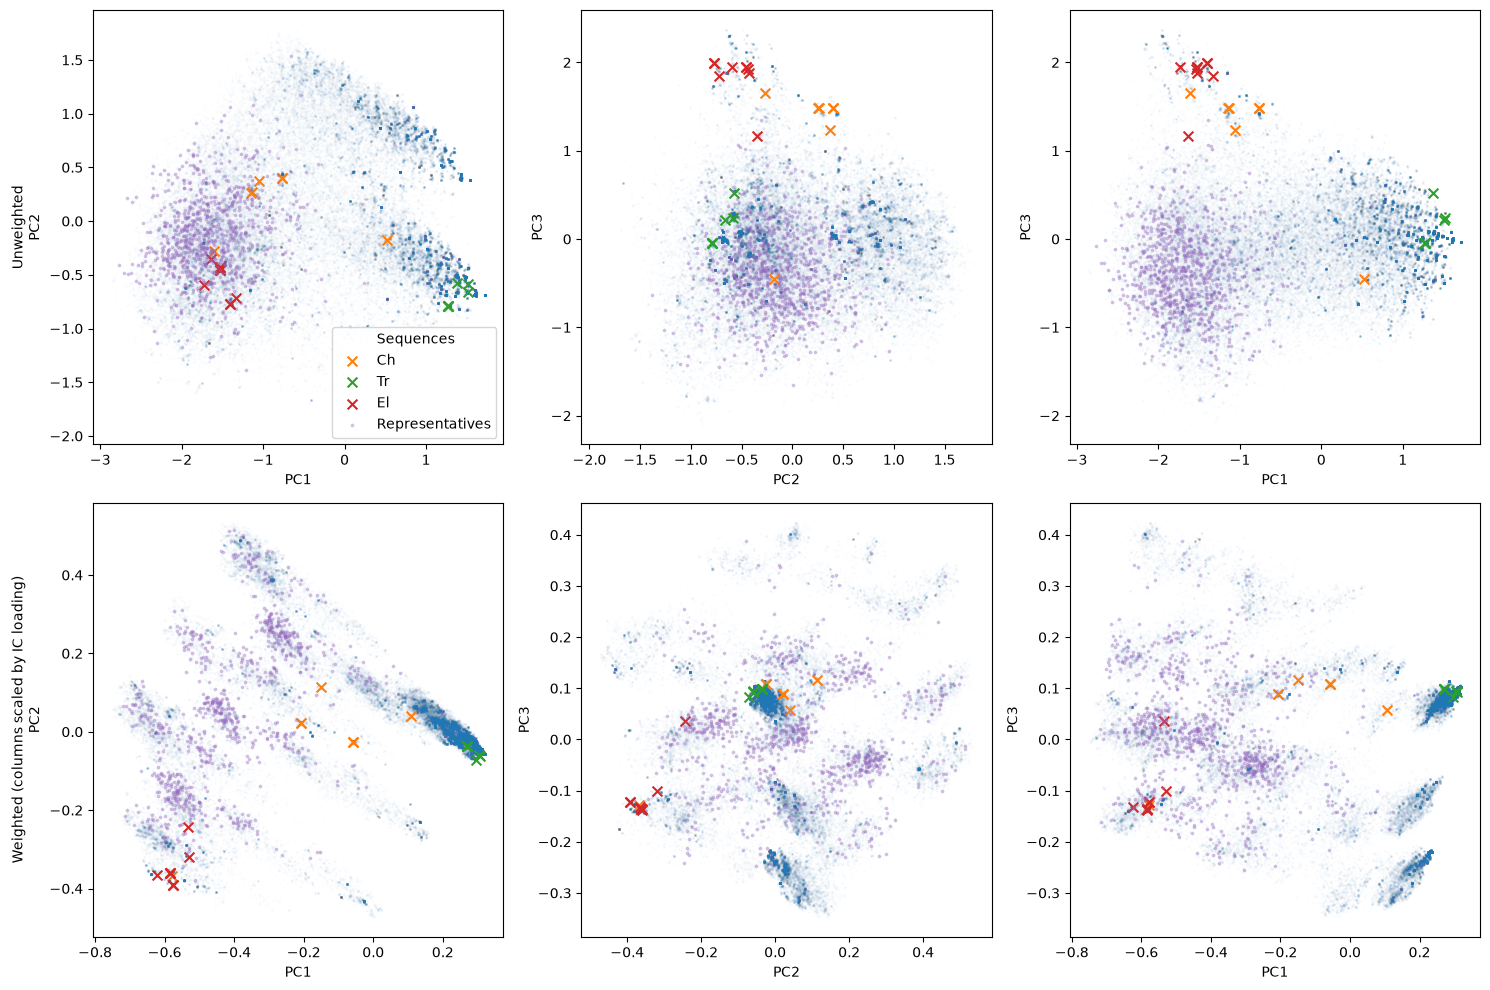

In [20]:
ohe = OneHotEncoder(handle_unknown='ignore')
reference_seqs_ohe = ohe.fit_transform(reference_seqs)

# broadcast each position's IC weight over all its one-hot columns
col_weights = np.concatenate([
    np.full(len(cats), w) for cats, w in zip(ohe.categories_, weights_sorted)
])
reference_seqs_ohe_weighted = reference_seqs_ohe.multiply(col_weights).tocsr()

pca = PCA(n_components=3, svd_solver='arpack')
pca.fit(reference_seqs_ohe_weighted)
reference_pca_weighted = pca.transform(reference_seqs_ohe_weighted)

pc_pairs = [(0, 1), (1, 2), (0, 2)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (reference_pca, row_title) in enumerate([
    (reference_pca_unweighted, "Unweighted"),
    (reference_pca_weighted, "Weighted (columns scaled by IC loading)"),
]):
    for col, (pc_a, pc_b) in enumerate(pc_pairs):
        ax = axes[row, col]
        ax.scatter(reference_pca[:, pc_a], reference_pca[:, pc_b], s=1, alpha=.01, label="Sequences")
        ax.scatter(reference_pca[ch_idxs, pc_a], reference_pca[ch_idxs, pc_b], s=50, alpha=1, label="Ch", marker="x")
        ax.scatter(reference_pca[tr_idxs, pc_a], reference_pca[tr_idxs, pc_b], s=50, alpha=1, label="Tr", marker="x")
        ax.scatter(reference_pca[el_idxs, pc_a], reference_pca[el_idxs, pc_b], s=50, alpha=1, label="El", marker="x")
        ax.scatter(reference_pca[representatives, pc_a], reference_pca[representatives, pc_b], s=3, alpha=.3, color="tab:purple", label="Representatives")
        ax.set_xlabel(f'PC{pc_a+1}')
        ax.set_ylabel(f'PC{pc_b+1}')
    axes[row, 0].set_ylabel(f"{row_title}\nPC{pc_pairs[0][1]+1}")

axes[0, 0].legend()
plt.tight_layout()
plt.show()

## t-SNE of red sector (weighted)

We also run t-SNE on the same weighted one-hot encoding (columns scaled by ICA loading), using the same Ch/Tr/El accessions as reference points. t-SNE doesn't scale well to the full ~90k-sequence alignment, so we embed only the dereplicated representative set plus the Ch/Tr/El references.

Found set of representative sequences! Size is 899


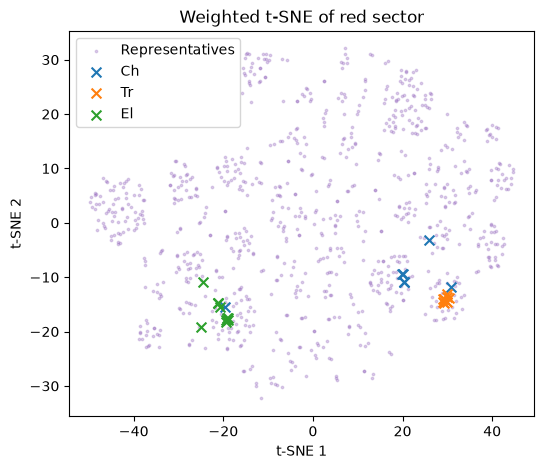

In [21]:
from sklearn.manifold import TSNE

seed = 42
representatives = find_representative(seqs_red, identity_threshold=7, seed=seed)
tsne_idxs = np.array(sorted(set(representatives) | set(ch_idxs) | set(tr_idxs) | set(el_idxs)))

ohe = OneHotEncoder(handle_unknown='ignore')
reference_seqs_ohe = ohe.fit_transform(reference_seqs)
col_weights = np.concatenate([
    np.full(len(cats), w) for cats, w in zip(ohe.categories_, weights_sorted)
])
reference_seqs_ohe_weighted = reference_seqs_ohe.multiply(col_weights).tocsr()

X_tsne_input = reference_seqs_ohe_weighted[tsne_idxs].toarray()

tsne = TSNE(n_components=2, init="pca", random_state=seed, perplexity=30)
embedding = tsne.fit_transform(X_tsne_input)

idx_to_pos = {idx: pos for pos, idx in enumerate(tsne_idxs)}
ch_pos = [idx_to_pos[i] for i in ch_idxs if i in idx_to_pos]
tr_pos = [idx_to_pos[i] for i in tr_idxs if i in idx_to_pos]
el_pos = [idx_to_pos[i] for i in el_idxs if i in idx_to_pos]
rep_pos = [idx_to_pos[i] for i in representatives if i in idx_to_pos]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(embedding[rep_pos, 0], embedding[rep_pos, 1], s=3, alpha=.3, color="tab:purple", label="Representatives")
ax.scatter(embedding[ch_pos, 0], embedding[ch_pos, 1], s=50, alpha=1, label="Ch", marker="x")
ax.scatter(embedding[tr_pos, 0], embedding[tr_pos, 1], s=50, alpha=1, label="Tr", marker="x")
ax.scatter(embedding[el_pos, 0], embedding[el_pos, 1], s=50, alpha=1, label="El", marker="x")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Weighted t-SNE of red sector")
plt.legend()
plt.show()

In [22]:
import numpy as np

# Expand dimensions to compare all pairs:
# seqs_red[None, :, :] -> (1, N, L)
# seqs_red[:, None, :] -> (N, 1, L)
# mismatches[i, j, k] = (seqs_red[i, k] != seqs_red[j, k])
mismatches = (seqs_red_rep[None, :, :] != seqs_red_rep[:, None, :])  # shape (N, N, L)

# Hamming distance = number of mismatches along the sequence axis
hamming_dist = mismatches.sum(axis=2)  # shape (N, N)

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [22]:
dist_condensed = squareform(hamming_dist, checks=False)
Z = linkage(dist_condensed, method="ward")

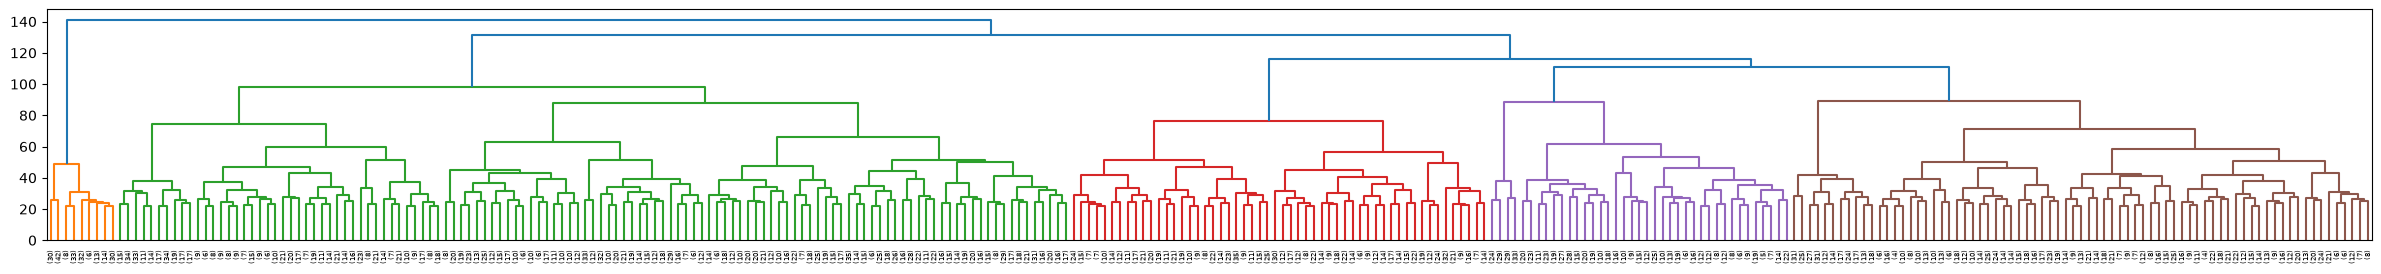

In [29]:
plt.figure(figsize=(30,3))
dendrogram(Z, truncate_mode="lastp", p=300)
plt.show()

# Sandbox